# EDA — INE Census 2021 (Source 3)

**Source:** Censos de Población y Viviendas 2021 (INE), processed by IneAtlas  
**S3:** `s3://hsf-group-ai-spain-hvac/ineatlas/generated/censo2021_secciones.parquet`  
**Local:** `data/generated/ineatlas/censo2021_secciones.parquet`  
**Documentation:** `GENERATED_DATA.md` (t-code mapping), `INE_ADRH_DATA_DOCUMENTATION.md`

This notebook covers:
1. Data overview — shape, coverage, dtypes
2. Demographics — age, sex, nationality
3. Labour market & pensions — key HVAC demand signals
4. Housing tenure — homeownership distribution
5. Household composition — size distribution
6. Regional heatmap — CCAA-level aggregation
7. Merge with ADRH — correlation between income and census signals

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

GENERATED_INEATLAS = Path("data/generated/ineatlas")
GENERATED_ADRH    = Path("data/generated/adrh")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", "{:.4f}".format)

## 1. Load and inspect

In [2]:
df = pd.read_parquet(GENERATED_INEATLAS / "censo2021_secciones.parquet")
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (36333, 41)

Dtypes:
cod_seccion                                str
cod_distrito                               str
cod_municipio                              str
cod_provincia                              str
poblacion_total                          int64
pct_mujeres                            float64
pct_hombres                            float64
edad_media                             float64
pct_menores_16                         float64
pct_16_64                              float64
pct_mayores_64                         float64
pct_extranjeros                        float64
pct_nacidos_extranjero                 float64
pct_cursando_estudios_superiores       float64
pct_cursando_universidad               float64
pct_estudios_superiores_completados    float64
tasa_paro                              float64
tasa_empleo                            float64
tasa_actividad                         float64
pct_pension_invalidez                  float64
pct_pension_jubilacion          

In [3]:
# Coverage: % non-null per column
cov = df.notna().mean().sort_values()
print("Columns with <100% coverage:")
print(cov[cov < 1.0].to_string())
print(f"\n{(cov == 1.0).sum()} columns fully populated")

Columns with <100% coverage:
pct_hombres                           0.9625
edad_media                            0.9625
pct_mujeres                           0.9625
pct_nacidos_extranjero                0.9625
pct_extranjeros                       0.9625
pct_mayores_64                        0.9625
pct_16_64                             0.9625
pct_menores_16                        0.9625
pct_cursando_universidad              0.9625
pct_cursando_estudios_superiores      0.9625
pct_estudios_superiores_completados   0.9625
pct_pension_jubilacion                0.9625
pct_pension_invalidez                 0.9625
tasa_actividad                        0.9625
tasa_empleo                           0.9625
tasa_paro                             0.9625
pct_casado                            0.9625
pct_viudo                             0.9625
pct_estado_civil_desconocido          0.9625
pct_separado_divorciado               0.9625
total_viviendas                       0.9625
pct_otra_inactividad      

In [4]:
# Basic descriptive stats for key numeric columns
key_cols = [
    "poblacion_total", "edad_media",
    "pct_extranjeros", "tasa_paro", "tasa_empleo",
    "pct_pension_jubilacion", "pct_pension_invalidez",
    "viviendas_en_propiedad", "viviendas_en_alquiler",
    "total_hogares", "pct_mayores_64",
]
df[key_cols].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
poblacion_total,36333.0000,1304.6211,677.8972,1.0000,895.0000,1260.0000,1692.0000,11002.0000
edad_media,34970.0000,45.2092,5.1541,27.2830,42.0062,44.9450,48.0391,70.9724
pct_extranjeros,34970.0000,0.1021,0.0895,0.0000,0.0374,0.0767,0.1405,0.8887
tasa_paro,34970.0000,0.1724,0.0818,0.0000,0.1155,0.1571,0.2118,0.8190
tasa_empleo,34970.0000,0.4551,0.0826,0.1104,0.4031,0.4514,0.5022,0.9006
pct_pension_jubilacion,34970.0000,0.1840,0.0668,0.0059,0.1395,0.1794,0.2232,0.5043
pct_pension_invalidez,34970.0000,0.0269,0.0135,0.0000,0.0173,0.0249,0.0342,0.2200
viviendas_en_propiedad,34970.0000,399.2854,186.3472,16.0000,281.0000,382.0000,503.0000,4113.0000
viviendas_en_alquiler,34970.0000,85.1612,68.7452,0.0000,37.0000,68.0000,113.0000,1031.0000
total_hogares,34970.0000,529.0318,243.6083,21.0000,378.0000,508.0000,662.0000,5472.0000


## 2. Demographics

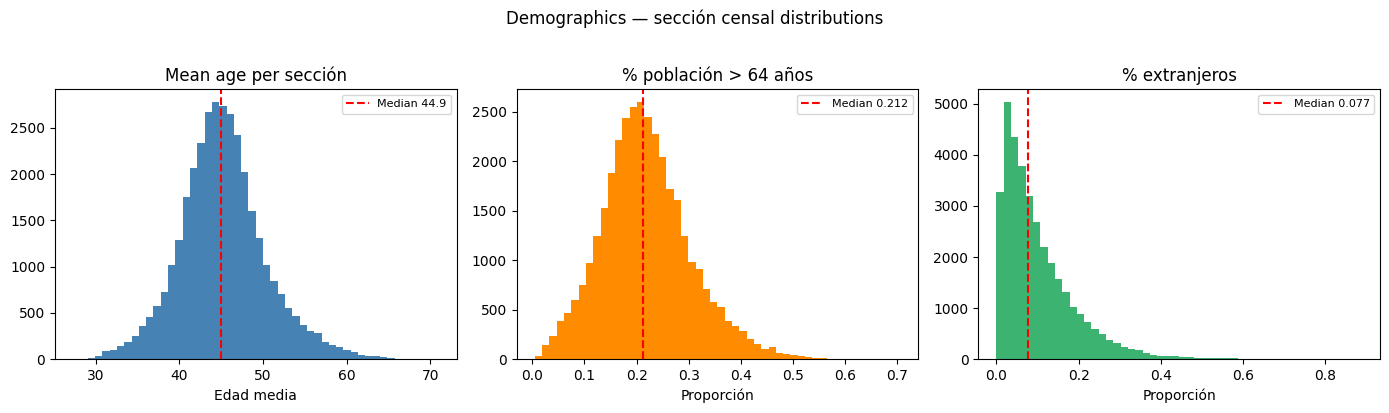

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["edad_media"].dropna(), bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Mean age per sección")
axes[0].set_xlabel("Edad media")
axes[0].axvline(df["edad_media"].median(), color="red", ls="--", label=f'Median {df["edad_media"].median():.1f}')
axes[0].legend(fontsize=8)

axes[1].hist(df["pct_mayores_64"].dropna(), bins=50, color="darkorange", edgecolor="none")
axes[1].set_title("% población > 64 años")
axes[1].set_xlabel("Proporción")
axes[1].axvline(df["pct_mayores_64"].median(), color="red", ls="--",
                label=f'Median {df["pct_mayores_64"].median():.3f}')
axes[1].legend(fontsize=8)

axes[2].hist(df["pct_extranjeros"].dropna(), bins=50, color="mediumseagreen", edgecolor="none")
axes[2].set_title("% extranjeros")
axes[2].set_xlabel("Proporción")
axes[2].axvline(df["pct_extranjeros"].median(), color="red", ls="--",
                label=f'Median {df["pct_extranjeros"].median():.3f}')
axes[2].legend(fontsize=8)

plt.suptitle("Demographics — sección censal distributions", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 3. Labour market & pensions

Key HVAC demand signals:
- **`pct_pension_jubilacion`** — share of population 16+ receiving retirement pension. High pension share → older residents → higher baseline heating demand and more time at home.
- **`tasa_paro`** — unemployment rate. Affects ability to invest in HVAC.

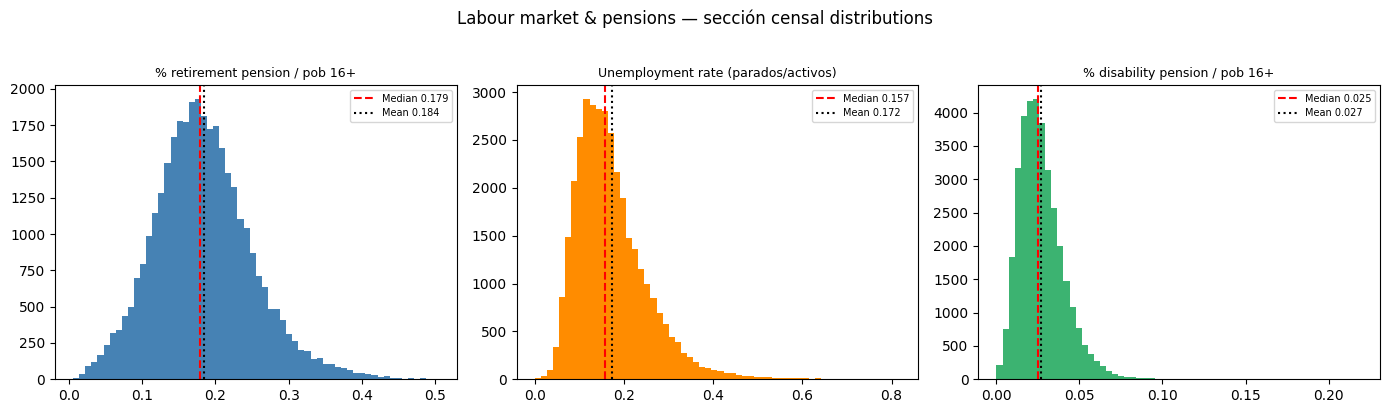

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color, label in [
    (axes[0], "pct_pension_jubilacion", "steelblue",  "% retirement pension / pob 16+"),
    (axes[1], "tasa_paro",              "darkorange",  "Unemployment rate (parados/activos)"),
    (axes[2], "pct_pension_invalidez",  "mediumseagreen", "% disability pension / pob 16+"),
]:
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, edgecolor="none")
    ax.axvline(data.median(), color="red", ls="--", label=f"Median {data.median():.3f}")
    ax.axvline(data.mean(),   color="black", ls=":",  label=f"Mean {data.mean():.3f}")
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Labour market & pensions — sección censal distributions", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

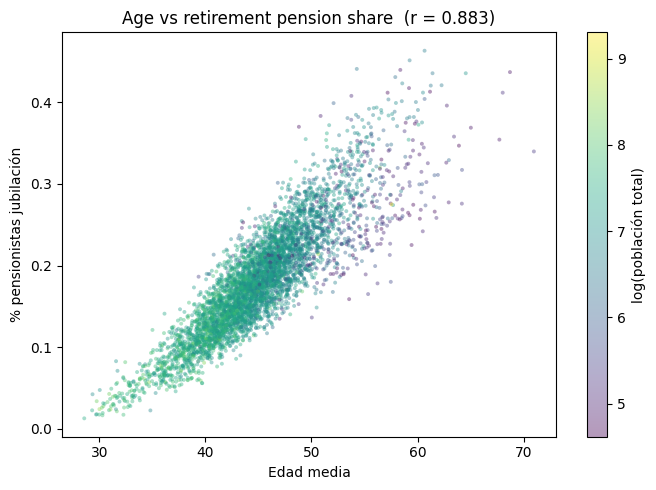

In [7]:
# Pension share vs age: expected strong positive correlation
fig, ax = plt.subplots(figsize=(7, 5))
sample = df[["edad_media", "pct_pension_jubilacion", "poblacion_total"]].dropna().sample(5000, random_state=42)
sc = ax.scatter(
    sample["edad_media"], sample["pct_pension_jubilacion"],
    c=np.log1p(sample["poblacion_total"]), cmap="viridis",
    alpha=0.4, s=8, linewidths=0,
)
plt.colorbar(sc, ax=ax, label="log(población total)")
r = sample[["edad_media", "pct_pension_jubilacion"]].corr().iloc[0, 1]
ax.set_xlabel("Edad media")
ax.set_ylabel("% pensionistas jubilación")
ax.set_title(f"Age vs retirement pension share  (r = {r:.3f})")
plt.tight_layout()
plt.show()

## 4. Housing tenure

**`viviendas_en_propiedad`** (owned dwellings, absolute count) is a key HVAC signal: owners are far more likely to invest in heating/cooling systems than renters.

The IneAtlas Census file stores tenure as absolute counts (not rates). We derive the ownership rate as `viviendas_en_propiedad / total_viviendas`.

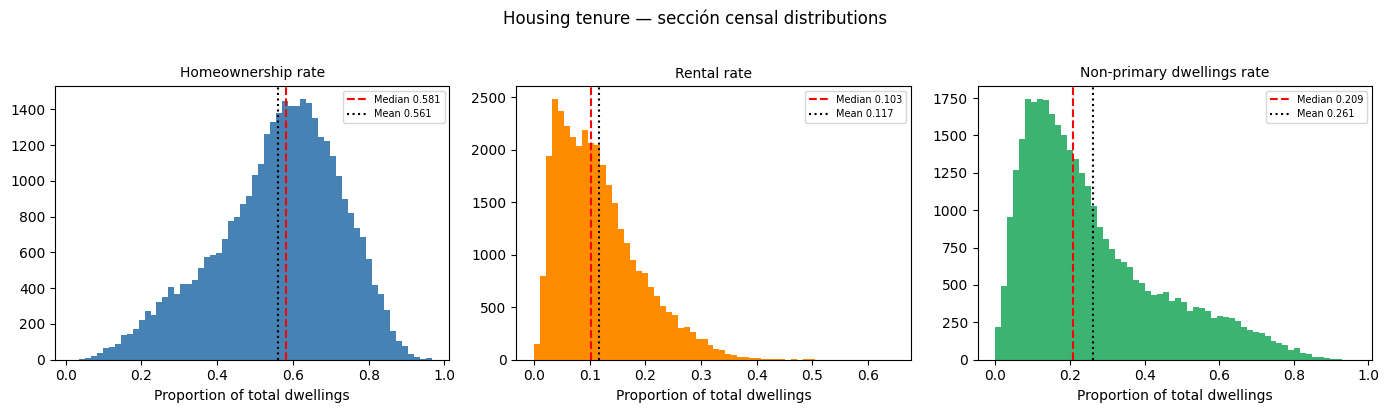

In [8]:
df["pct_propiedad"] = df["viviendas_en_propiedad"] / df["total_viviendas"]
df["pct_alquiler"]  = df["viviendas_en_alquiler"]  / df["total_viviendas"]
df["pct_no_principal"] = df["viviendas_no_principales"] / df["total_viviendas"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color, label in [
    (axes[0], "pct_propiedad",    "steelblue",       "Homeownership rate"),
    (axes[1], "pct_alquiler",     "darkorange",      "Rental rate"),
    (axes[2], "pct_no_principal", "mediumseagreen",  "Non-primary dwellings rate"),
]:
    data = df[col].dropna()
    ax.hist(data, bins=60, color=color, edgecolor="none")
    ax.axvline(data.median(), color="red", ls="--", label=f"Median {data.median():.3f}")
    ax.axvline(data.mean(),   color="black", ls=":",  label=f"Mean {data.mean():.3f}")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Proportion of total dwellings")
    ax.legend(fontsize=7)

plt.suptitle("Housing tenure — sección censal distributions", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

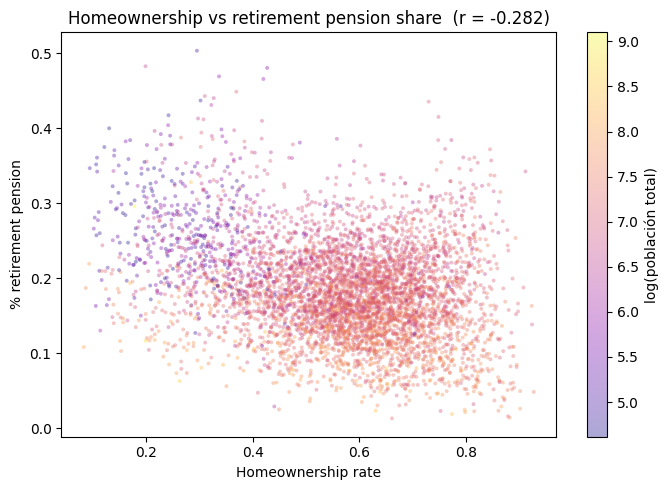

In [9]:
# Homeownership vs pension share: owners tend to be older
sample2 = df[["pct_propiedad", "pct_pension_jubilacion", "poblacion_total"]].dropna().sample(5000, random_state=0)
r2 = sample2[["pct_propiedad", "pct_pension_jubilacion"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    sample2["pct_propiedad"], sample2["pct_pension_jubilacion"],
    c=np.log1p(sample2["poblacion_total"]), cmap="plasma",
    alpha=0.35, s=8, linewidths=0,
)
plt.colorbar(sc, ax=ax, label="log(población total)")
ax.set_xlabel("Homeownership rate")
ax.set_ylabel("% retirement pension")
ax.set_title(f"Homeownership vs retirement pension share  (r = {r2:.3f})")
plt.tight_layout()
plt.show()

## 5. Household composition

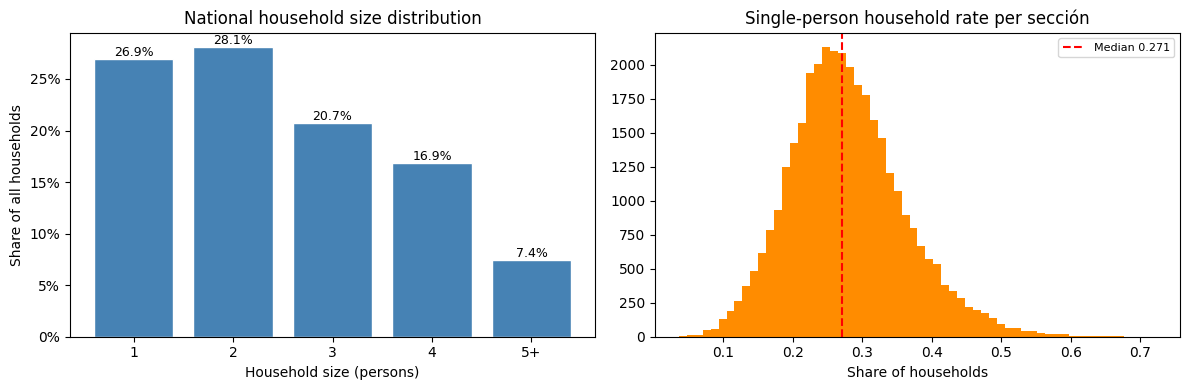

In [10]:
hh_cols = ["hogares_1_persona", "hogares_2_personas", "hogares_3_personas",
           "hogares_4_personas", "hogares_5_mas_personas"]
hh_labels = ["1", "2", "3", "4", "5+"]

# National share of each household size
hh_total = df[hh_cols].sum()
hh_share = hh_total / hh_total.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(hh_labels, hh_share.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Household size (persons)")
axes[0].set_ylabel("Share of all households")
axes[0].set_title("National household size distribution")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for i, v in enumerate(hh_share.values):
    axes[0].text(i, v + 0.003, f"{v:.1%}", ha="center", fontsize=9)

# Distribution of single-person household share across secciones
df["pct_hh_unipersonal"] = df["hogares_1_persona"] / df["total_hogares"]
axes[1].hist(df["pct_hh_unipersonal"].dropna(), bins=60, color="darkorange", edgecolor="none")
med = df["pct_hh_unipersonal"].median()
axes[1].axvline(med, color="red", ls="--", label=f"Median {med:.3f}")
axes[1].set_title("Single-person household rate per sección")
axes[1].set_xlabel("Share of households")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Regional heatmap (CCAA level)

Aggregation: median across secciones within each province, then median of province medians within each CCAA.  
Colour: Z-score within each column. Raw values annotated.

In [11]:
prov_to_region = {
     1:"País Vasco",          2:"Castilla-La Mancha",   3:"Comunitat Valenciana",
     4:"Andalucía",           5:"Castilla y León",      6:"Extremadura",
     7:"Illes Balears",       8:"Cataluña",             9:"Castilla y León",
    10:"Extremadura",         11:"Andalucía",           12:"Comunitat Valenciana",
    13:"Castilla-La Mancha",  14:"Andalucía",           15:"Galicia",
    16:"Castilla-La Mancha",  17:"Cataluña",            18:"Andalucía",
    19:"Castilla-La Mancha",  20:"País Vasco",          21:"Andalucía",
    22:"Aragón",              23:"Andalucía",           24:"Castilla y León",
    25:"Cataluña",            26:"La Rioja",            27:"Galicia",
    28:"Comunidad de Madrid", 29:"Andalucía",           30:"Región de Murcia",
    31:"Comunidad Foral de Navarra", 32:"Galicia",      33:"Principado de Asturias",
    34:"Castilla y León",     35:"Canarias",            36:"Galicia",
    37:"Castilla y León",     38:"Canarias",            39:"Cantabria",
    40:"Castilla y León",     41:"Andalucía",           42:"Castilla y León",
    43:"Cataluña",            44:"Aragón",              45:"Castilla-La Mancha",
    46:"Comunitat Valenciana",47:"Castilla y León",     48:"País Vasco",
    49:"Castilla y León",     50:"Aragón",
    51:"Ceuta",               52:"Melilla",
}

df["prov_code"] = df["cod_seccion"].str[:2].astype(int)
df["region"]    = df["prov_code"].map(prov_to_region)

hvac_cols = [
    "edad_media", "pct_mayores_64",
    "pct_pension_jubilacion",
    "tasa_paro",
    "pct_propiedad",
    "pct_no_principal",
    "pct_hh_unipersonal",
    "poblacion_total",
]

prov_agg = df.groupby("prov_code")[hvac_cols].median()
prov_agg["region"] = prov_agg.index.map(prov_to_region)
ccaa_agg = prov_agg.groupby("region")[hvac_cols].median().sort_index()

print("CCAA aggregation shape:", ccaa_agg.shape)
ccaa_agg.round(3)

CCAA aggregation shape: (19, 8)


,edad_media,pct_mayores_64,pct_pension_jubilacion,tasa_paro,pct_propiedad,pct_no_principal,pct_hh_unipersonal,poblacion_total
region,,,,,,,,
Andalucía,43.6000,0.1900,0.1600,0.2320,0.6120,0.2260,0.2590,1326.0000
Aragón,47.9990,0.2610,0.2060,0.1090,0.4010,0.4590,0.3170,480.0000
Canarias,43.9370,0.1780,0.1380,0.2460,0.5330,0.1780,0.2480,1460.0000
Cantabria,47.5780,0.2460,0.2060,0.1550,0.5570,0.2620,0.3000,1184.0000
Castilla y León,51.6510,0.3130,0.2370,0.1310,0.4250,0.4770,0.3610,314.0000
Castilla-La Mancha,45.7280,0.2210,0.1640,0.1850,0.4910,0.3570,0.2880,1113.0000
Cataluña,43.6810,0.1990,0.1890,0.1160,0.4990,0.2900,0.2570,1474.5000
Ceuta,39.0200,0.1190,0.0990,0.2740,0.6310,0.0930,0.1960,1393.0000
Comunidad Foral de Navarra,45.3660,0.2250,0.2070,0.1280,0.6150,0.2230,0.2830,1128.0000


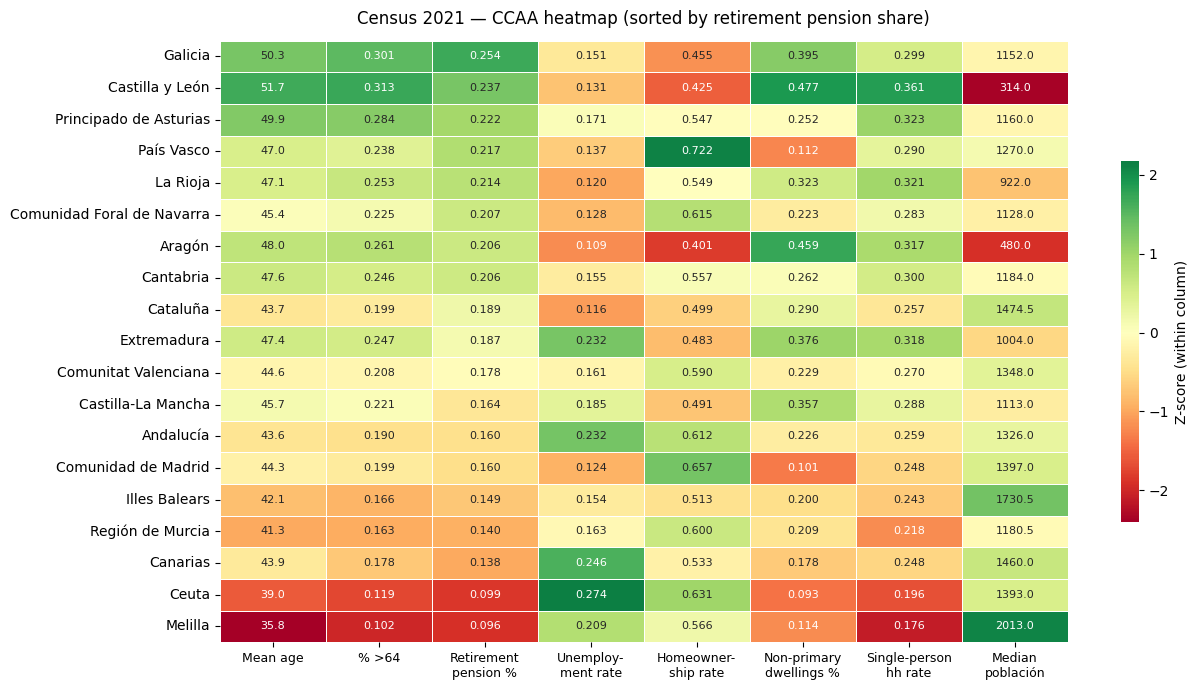

In [12]:
short_labels = {
    "edad_media":             "Mean age",
    "pct_mayores_64":         "% >64",
    "pct_pension_jubilacion": "Retirement\npension %",
    "tasa_paro":              "Unemploy-\nment rate",
    "pct_propiedad":          "Homeowner-\nship rate",
    "pct_no_principal":       "Non-primary\ndwellings %",
    "pct_hh_unipersonal":     "Single-person\nhh rate",
    "poblacion_total":        "Median\npoblación",
}

heat_raw = ccaa_agg[hvac_cols].copy()
heat_raw = heat_raw.sort_values("pct_pension_jubilacion", ascending=False)
heat_raw.columns = [short_labels[c] for c in hvac_cols]
heat_z = (heat_raw - heat_raw.mean()) / heat_raw.std()

def _fmt(col, series):
    if col in ("Mean age", "Median\npoblación"):
        return series.map(lambda v: f"{v:.1f}" if pd.notna(v) else "")
    return series.map(lambda v: f"{v:.3f}" if pd.notna(v) else "")

annot = pd.DataFrame({c: _fmt(c, heat_raw[c]) for c in heat_raw.columns}, index=heat_raw.index)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    heat_z, ax=ax, cmap="RdYlGn", center=0, linewidths=0.4,
    cbar_kws={"label": "Z-score (within column)", "shrink": 0.6},
    annot=annot, fmt="", annot_kws={"size": 8},
)
ax.set_title("Census 2021 — CCAA heatmap (sorted by retirement pension share)", fontsize=12, pad=12)
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
plt.tight_layout()
plt.show()

## 7. Merge with ADRH — income × census correlations

Join key: `cod_seccion` (10-char, exact match).  
ADRH provides income and inequality indicators at sección level; Census provides demographics and housing structure.

In [13]:
adrh = pd.read_parquet(GENERATED_ADRH / "adrh_secciones_latest.parquet")
print(f"ADRH shape: {adrh.shape}")
print(f"Census shape: {df.shape}")

merged = df.merge(adrh[["cod_seccion", "renta_neta_media_por_hogar", "indice_de_gini",
                          "fuente_de_ingreso_pensiones", "fuente_de_ingreso_salario"]],
                  on="cod_seccion", how="inner")
print(f"\nMerged shape: {merged.shape}  ({merged.shape[0]/df.shape[0]:.1%} of census secciones matched)")

ADRH shape: (37034, 59)
Census shape: (36333, 47)

Merged shape: (36333, 51)  (100.0% of census secciones matched)


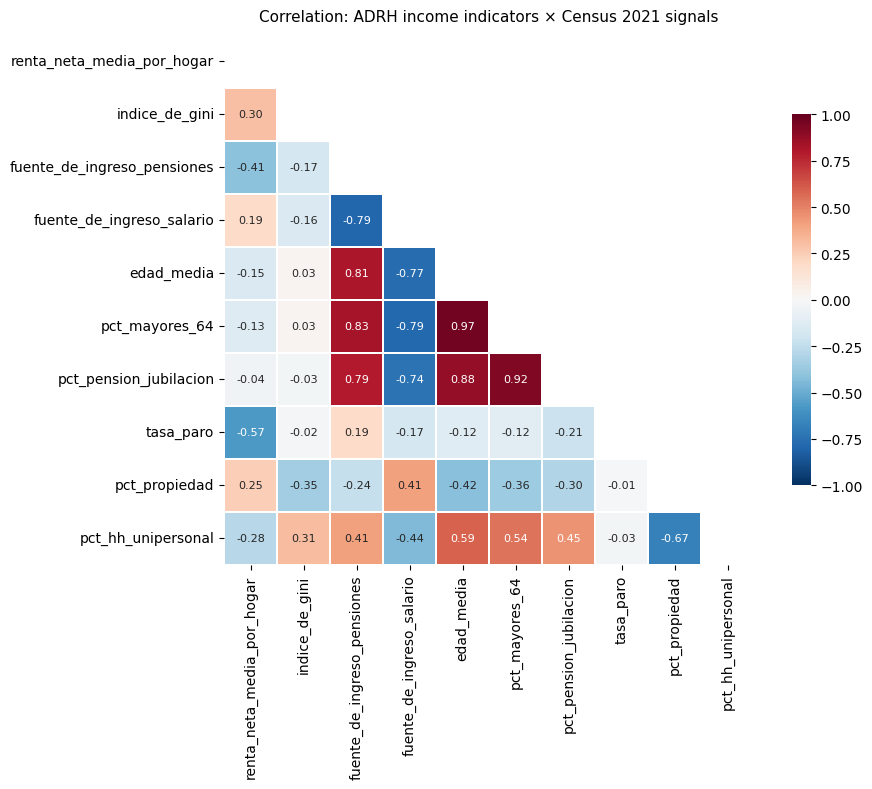

In [14]:
# Correlation matrix: census signals vs ADRH income
corr_cols = [
    "renta_neta_media_por_hogar", "indice_de_gini",
    "fuente_de_ingreso_pensiones", "fuente_de_ingreso_salario",
    "edad_media", "pct_mayores_64", "pct_pension_jubilacion",
    "tasa_paro", "pct_propiedad", "pct_hh_unipersonal",
]
corr = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, ax=ax, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    linewidths=0.3, square=True,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Correlation: ADRH income indicators × Census 2021 signals", fontsize=11, pad=10)
plt.tight_layout()
plt.show()

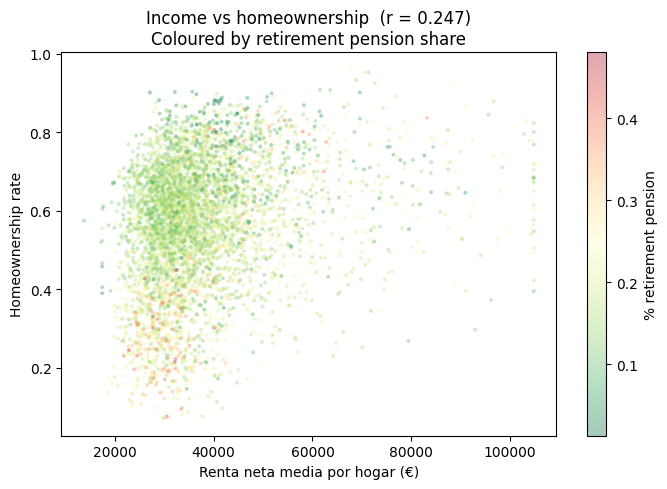

In [15]:
# Scatter: net household income vs homeownership rate
sample3 = merged[["renta_neta_media_por_hogar", "pct_propiedad", "pct_pension_jubilacion"]].dropna().sample(5000, random_state=1)
r3 = sample3[["renta_neta_media_por_hogar", "pct_propiedad"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    sample3["renta_neta_media_por_hogar"], sample3["pct_propiedad"],
    c=sample3["pct_pension_jubilacion"], cmap="RdYlGn_r",
    alpha=0.35, s=8, linewidths=0,
)
plt.colorbar(sc, ax=ax, label="% retirement pension")
ax.set_xlabel("Renta neta media por hogar (€)")
ax.set_ylabel("Homeownership rate")
ax.set_title(f"Income vs homeownership  (r = {r3:.3f})\nColoured by retirement pension share")
plt.tight_layout()
plt.show()

## 8. Temperature reference by province / CCAA

Mean annual temperatures at province level — reference climatological averages from Open-Meteo.  
Climate zone is an independent HVAC demand driver: cold provinces (interior plateau, north) drive heating; hot provinces (south, Mediterranean coast) drive AC.  
Source: Open-Meteo Climate API — https://open-meteo.com/

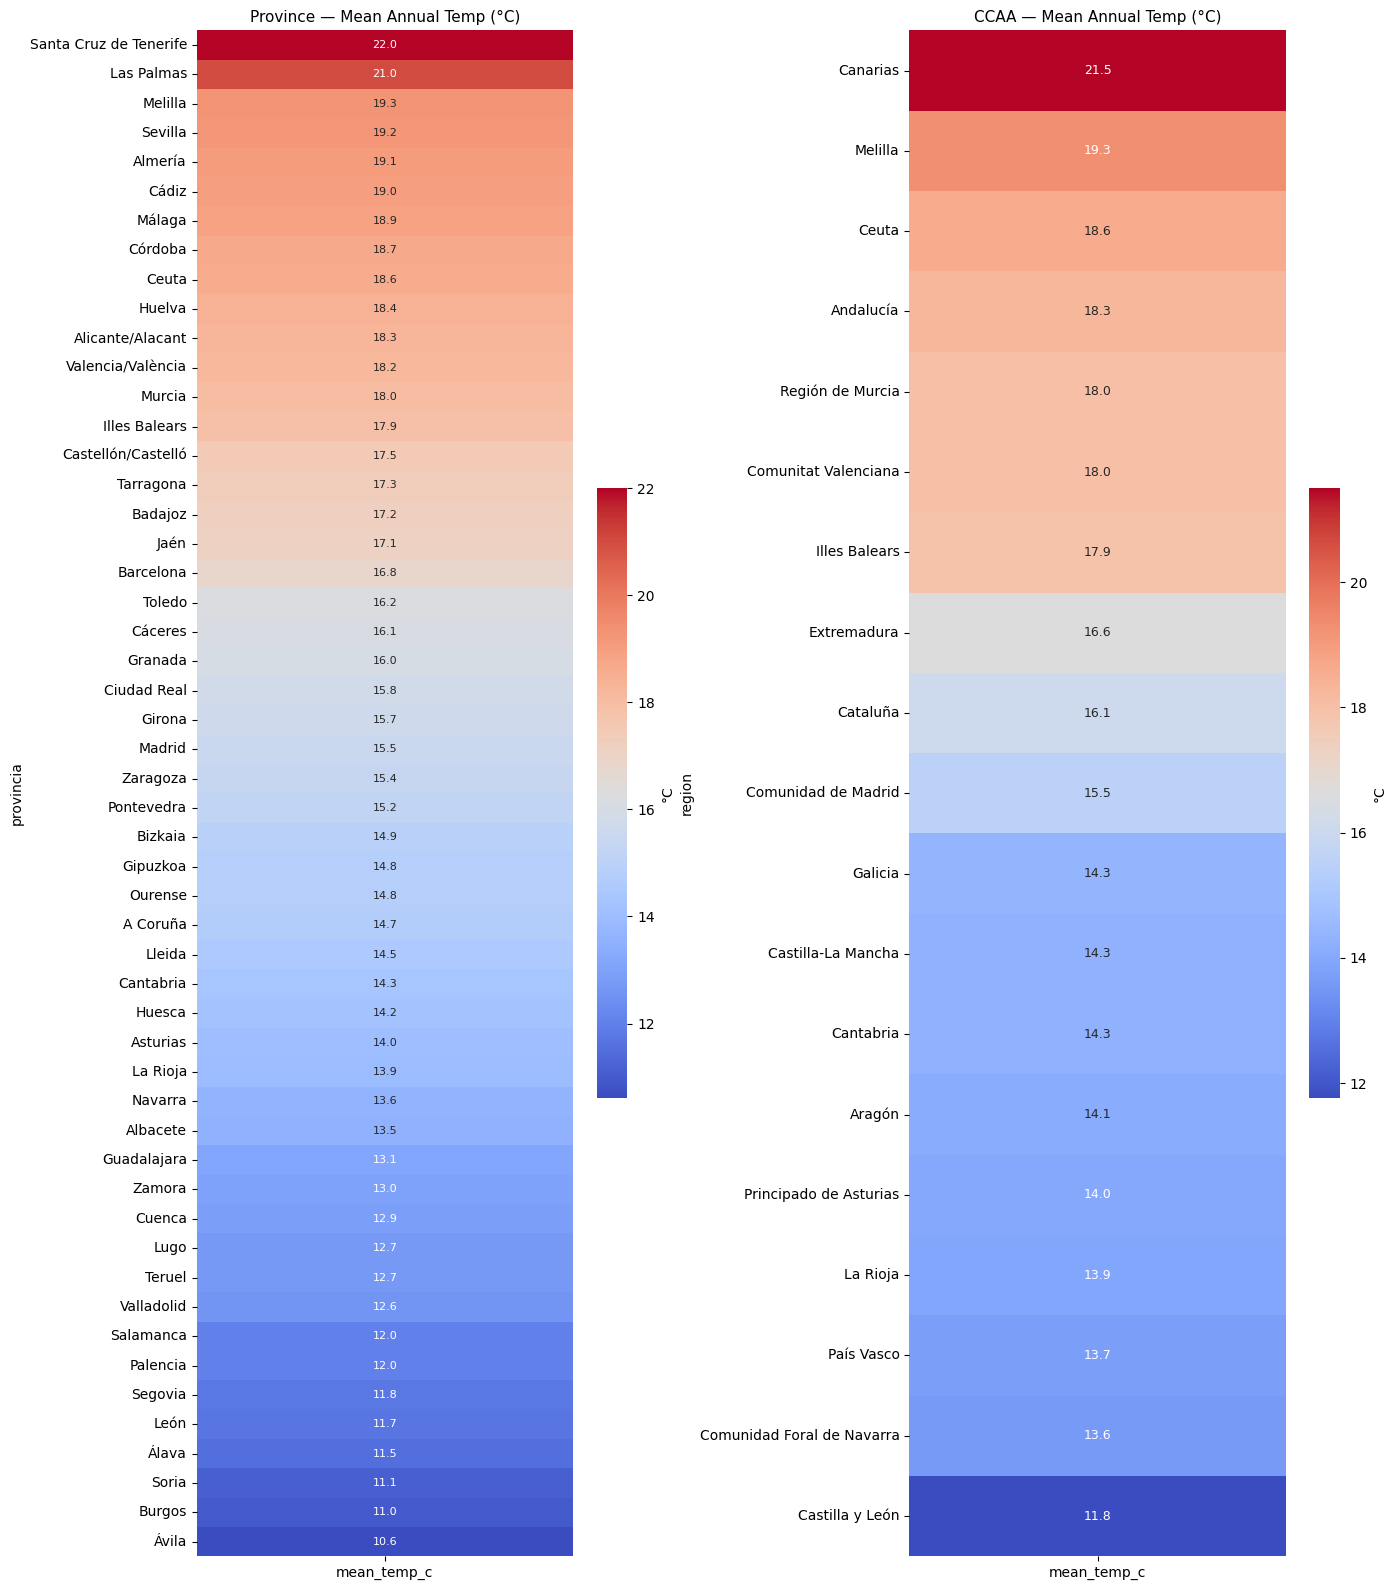

In [16]:
temp_data = [
    ("Álava", 11.5), ("Albacete", 13.5), ("Alicante/Alacant", 18.3), ("Almería", 19.1),
    ("Asturias", 14.0), ("Ávila", 10.6), ("Badajoz", 17.2), ("Illes Balears", 17.9),
    ("Barcelona", 16.8), ("Burgos", 11.0), ("Cáceres", 16.1), ("Cádiz", 19.0),
    ("Cantabria", 14.3), ("Castellón/Castelló", 17.5), ("Ciudad Real", 15.8),
    ("Córdoba", 18.7), ("A Coruña", 14.7), ("Cuenca", 12.9), ("Girona", 15.7),
    ("Granada", 16.0), ("Guadalajara", 13.1), ("Gipuzkoa", 14.8), ("Huelva", 18.4),
    ("Huesca", 14.2), ("Jaén", 17.1), ("León", 11.7), ("Lleida", 14.5), ("Lugo", 12.7),
    ("Madrid", 15.5), ("Málaga", 18.9), ("Murcia", 18.0), ("Navarra", 13.6),
    ("Ourense", 14.8), ("Palencia", 12.0), ("Las Palmas", 21.0), ("Pontevedra", 15.2),
    ("La Rioja", 13.9), ("Salamanca", 12.0), ("Santa Cruz de Tenerife", 22.0),
    ("Segovia", 11.8), ("Sevilla", 19.2), ("Soria", 11.1), ("Tarragona", 17.3),
    ("Teruel", 12.7), ("Toledo", 16.2), ("Valencia/València", 18.2), ("Valladolid", 12.6),
    ("Bizkaia", 14.9), ("Zamora", 13.0), ("Zaragoza", 15.4), ("Ceuta", 18.6), ("Melilla", 19.3),
]

prov_name_to_region = {
    "Álava": "País Vasco", "Albacete": "Castilla-La Mancha", "Alicante/Alacant": "Comunitat Valenciana",
    "Almería": "Andalucía", "Asturias": "Principado de Asturias", "Ávila": "Castilla y León",
    "Badajoz": "Extremadura", "Illes Balears": "Illes Balears", "Barcelona": "Cataluña",
    "Burgos": "Castilla y León", "Cáceres": "Extremadura", "Cádiz": "Andalucía",
    "Cantabria": "Cantabria", "Castellón/Castelló": "Comunitat Valenciana",
    "Ciudad Real": "Castilla-La Mancha", "Córdoba": "Andalucía", "A Coruña": "Galicia",
    "Cuenca": "Castilla-La Mancha", "Girona": "Cataluña", "Granada": "Andalucía",
    "Guadalajara": "Castilla-La Mancha", "Gipuzkoa": "País Vasco", "Huelva": "Andalucía",
    "Huesca": "Aragón", "Jaén": "Andalucía", "León": "Castilla y León", "Lleida": "Cataluña",
    "Lugo": "Galicia", "Madrid": "Comunidad de Madrid", "Málaga": "Andalucía",
    "Murcia": "Región de Murcia", "Navarra": "Comunidad Foral de Navarra", "Ourense": "Galicia",
    "Palencia": "Castilla y León", "Las Palmas": "Canarias", "Pontevedra": "Galicia",
    "La Rioja": "La Rioja", "Salamanca": "Castilla y León", "Santa Cruz de Tenerife": "Canarias",
    "Segovia": "Castilla y León", "Sevilla": "Andalucía", "Soria": "Castilla y León",
    "Tarragona": "Cataluña", "Teruel": "Aragón", "Toledo": "Castilla-La Mancha",
    "Valencia/València": "Comunitat Valenciana", "Valladolid": "Castilla y León",
    "Bizkaia": "País Vasco", "Zamora": "Castilla y León", "Zaragoza": "Aragón",
    "Ceuta": "Ceuta", "Melilla": "Melilla",
}

prov_temp = pd.DataFrame(temp_data, columns=["provincia", "mean_temp_c"])
prov_temp["region"] = prov_temp["provincia"].map(prov_name_to_region)

fig, axes = plt.subplots(1, 2, figsize=(14, 16))

prov_heat = prov_temp.sort_values("mean_temp_c", ascending=False).set_index("provincia")[["mean_temp_c"]]
sns.heatmap(prov_heat, ax=axes[0], annot=True, fmt=".1f", cmap="coolwarm",
            cbar_kws={"label": "°C", "shrink": 0.4}, annot_kws={"size": 8})
axes[0].set_title("Province — Mean Annual Temp (°C)", fontsize=11)

reg_temp = (
    prov_temp.groupby("region")["mean_temp_c"].mean()
    .sort_values(ascending=False)
    .to_frame()
)
sns.heatmap(reg_temp, ax=axes[1], annot=True, fmt=".1f", cmap="coolwarm",
            cbar_kws={"label": "°C", "shrink": 0.4}, annot_kws={"size": 9})
axes[1].set_title("CCAA — Mean Annual Temp (°C)", fontsize=11)

plt.tight_layout()
plt.show()